# 🩺 Disease Prediction from Medical Data — Breast Cancer Classification

**Objective:** Predict whether a breast tumor is **Malignant ** or **Benign ** using structured medical data (features derived from cell nuclei measurements).

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — available directly via `scikit-learn` (originally from UCI ML Repository).

**Algorithms compared:**
- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest
- XGBoost

**Pipeline:**
1. Load & explore the data (EDA)
2. Preprocess (scaling, train/test split)
3. Train multiple classification models
4. Evaluate & compare (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix)
5. Feature importance analysis
6. Final conclusion & best model selection

> 💡 **How to run:** Open this notebook in Google Colab (Runtime → Run all). All libraries used are pre-installed on Colab except `xgboost`, which is installed in the first cell.


## 1️⃣ Setup & Installation

In [20]:
# Install XGBoost (usually not pre-installed / may need upgrade on Colab)
!pip install -q xgboost --upgrade


In [21]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Config
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 2️⃣ Load the Dataset

We use the built-in **Breast Cancer Wisconsin (Diagnostic)** dataset from scikit-learn.
- **569 samples**, **30 numeric features** computed from digitized images of a breast mass (radius, texture, perimeter, area, smoothness, etc.)
- **Target:** `0 = malignant `, `1 = benign `


In [22]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
target_names = data.target_names  # ['malignant', 'benign']

print("Shape:", df.shape)
df.head()


Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [24]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 3️⃣ Exploratory Data Analysis (EDA)

In [25]:
# Check for missing values
print("Missing values per column:\n",
df.isnull().sum().sum(), "total missing values")


Missing values per column:
 0 total missing values


/tmp/ipykernel_1032/3715819232.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts.values, palette="Set2")


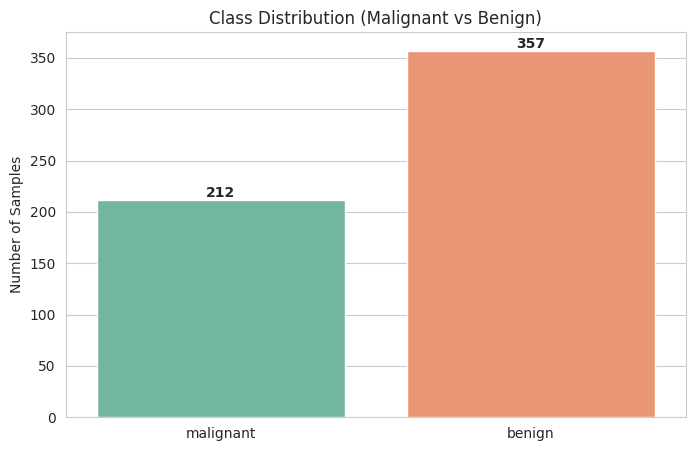

target
benign       62.741652
malignant    37.258348
Name: proportion, dtype: float64


In [26]:
# Class balance
counts = df['target'].value_counts().sort_index()
labels = [target_names[i] for i in counts.index]

plt.figure()
sns.barplot(x=labels, y=counts.values, palette="Set2")
plt.title("Class Distribution (Malignant vs Benign)")
plt.ylabel("Number of Samples")
for i, v in enumerate(counts.values):
    plt.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.show()

print(df['target'].value_counts(normalize=True).rename(index={0:'malignant',1:'benign'}) * 100)


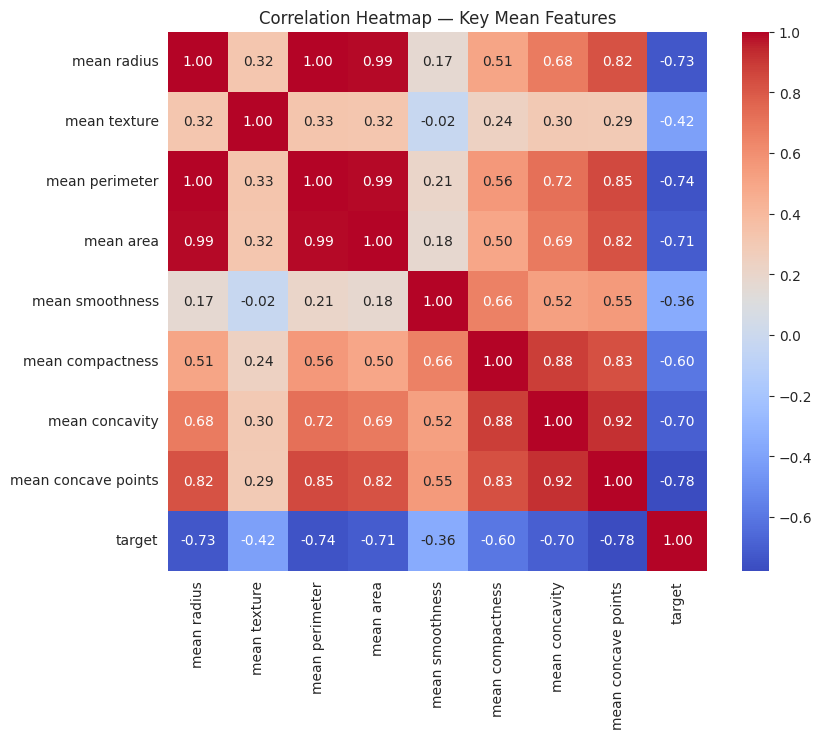

In [27]:
# Correlation heatmap of a subset of key features
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                 'mean smoothness', 'mean compactness', 'mean concavity',
                 'mean concave points', 'target']

plt.figure(figsize=(9, 7))
sns.heatmap(df[key_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap — Key Mean Features")
plt.show()


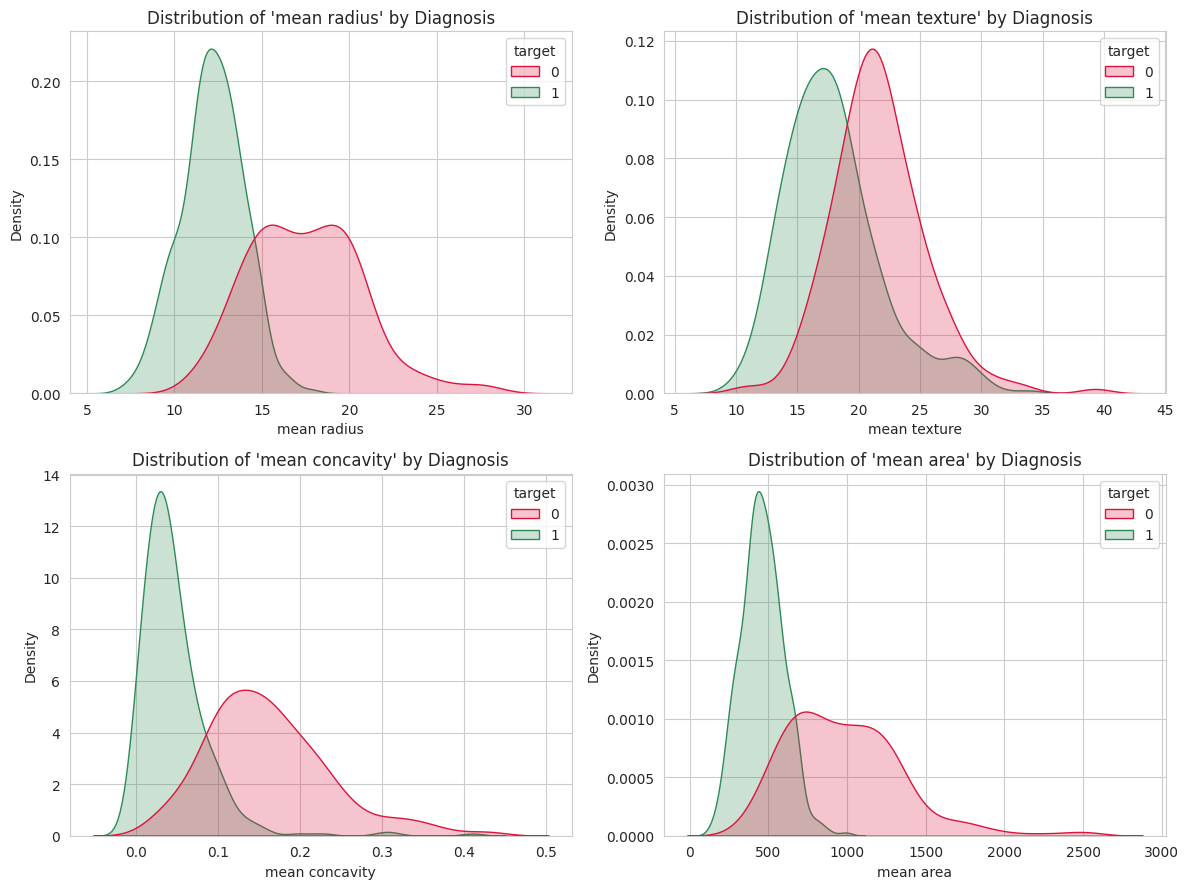

In [28]:
# Distribution of a few important features by class
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
feats_to_plot = ['mean radius', 'mean texture', 'mean concavity', 'mean area']

for ax, feat in zip(axes.flatten(), feats_to_plot):
    sns.kdeplot(data=df, x=feat, hue='target', fill=True, common_norm=False,
                palette={0: 'crimson', 1: 'seagreen'}, ax=ax)
    ax.set_title(f"Distribution of '{feat}' by Diagnosis")

plt.tight_layout()
plt.show()


## 4️⃣ Preprocessing

- Split features (X) and target (y)
- Train/test split (80/20), stratified to preserve class balance
- Standardize features (zero mean, unit variance) — important for SVM & Logistic Regression


In [29]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (455, 30)  Test shape: (114, 30)


## 5️⃣ Model Training

We train four classical & ensemble models. Tree-based models (Random Forest, XGBoost) don't strictly need scaling, but we use the scaled data consistently for a fair, simple comparison.


In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        eval_metric='logloss', random_state=RANDOM_STATE
    )
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"✅ Trained: {name}")


✅ Trained: Logistic Regression
✅ Trained: SVM (RBF Kernel)
✅ Trained: Random Forest
✅ Trained: XGBoost


## 6️⃣ Model Evaluation & Comparison

In [31]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
results_df.style.background_gradient(cmap="Greens", subset=results_df.columns[1:])


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,SVM (RBF Kernel),0.982456,0.986111,0.986111,0.986111,0.995040
2,XGBoost,0.956140,0.946667,0.986111,0.965986,0.993386
3,Random Forest,0.947368,0.958333,0.958333,0.958333,0.993717


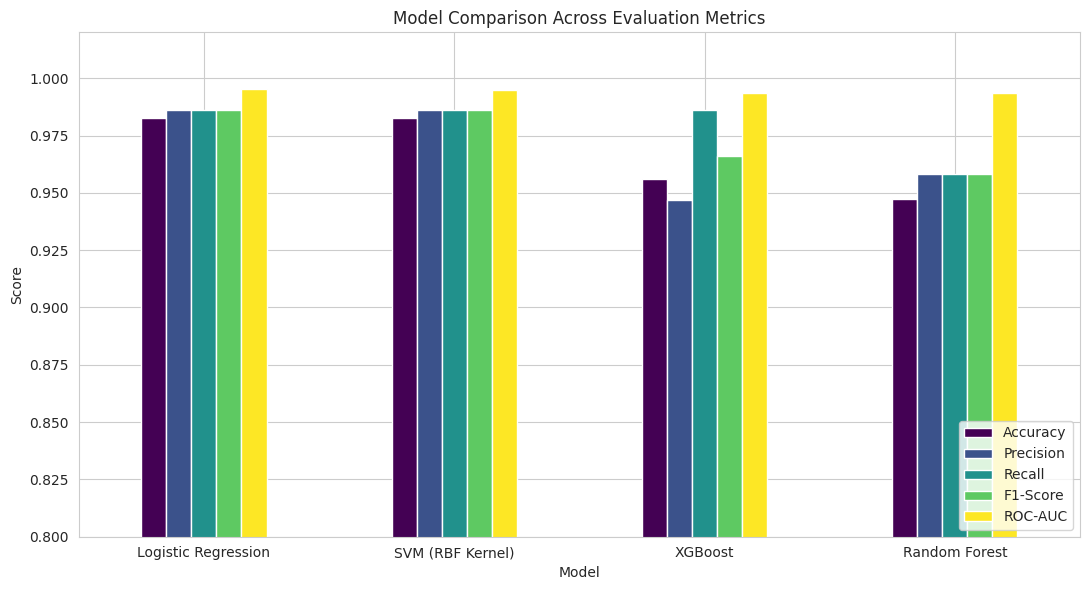

In [32]:
# Bar chart comparing all metrics across models
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
plot_df = results_df.set_index("Model")[metrics]

plot_df.plot(kind="bar", figsize=(11, 6), colormap="viridis")
plt.title("Model Comparison Across Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0.8, 1.02)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


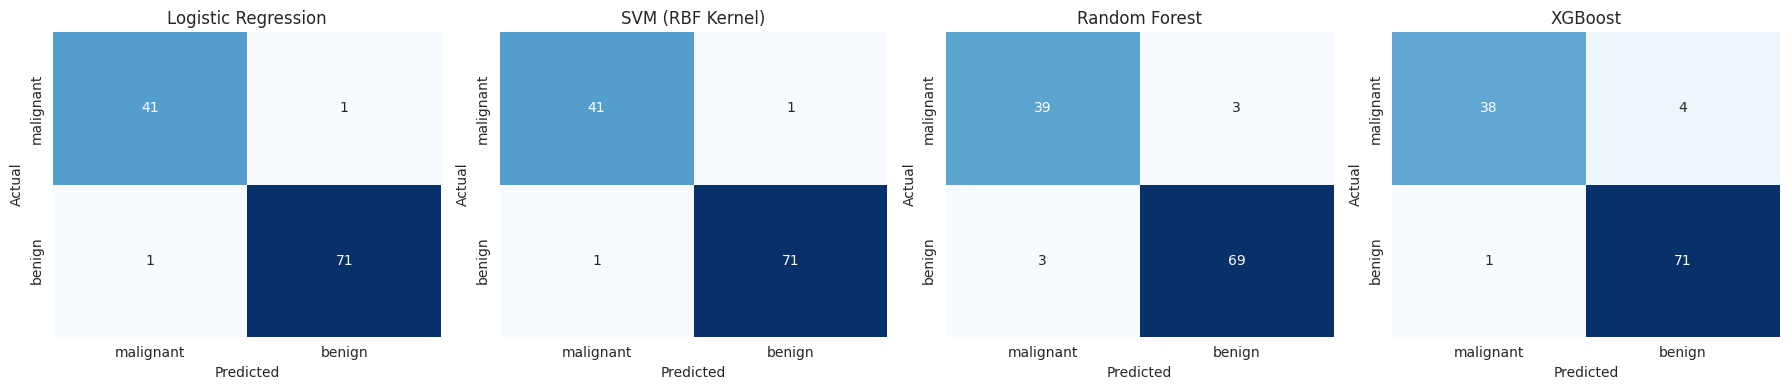

In [33]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, len(trained_models), figsize=(18, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


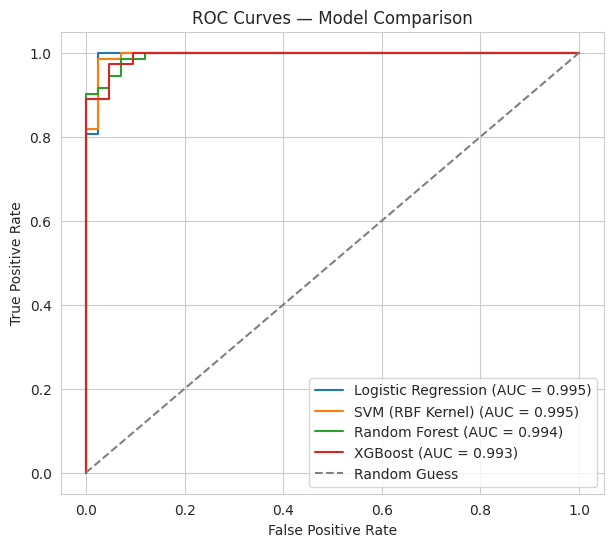

In [34]:
# ROC curves for all models
plt.figure(figsize=(7, 6))

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend(loc="lower right")
plt.show()


In [35]:
# Detailed classification report for the best model
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"📌 Best model based on F1-Score: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=target_names))


📌 Best model based on F1-Score: Logistic Regression

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 7️⃣ Cross-Validation (robustness check)

A single train/test split can be lucky/unlucky. We validate with 5-fold stratified cross-validation on the full (scaled) dataset.


In [36]:
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "CV F1 Mean": scores.mean(),
        "CV F1 Std": scores.std()
    })

cv_df = (
    pd.DataFrame(cv_results)
    .sort_values("CV F1 Mean", ascending=False)
    .reset_index(drop=True)
)

print(cv_df)

                 Model  CV F1 Mean  CV F1 Std
0     SVM (RBF Kernel)    0.981990   0.012829
1  Logistic Regression    0.979434   0.012725
2              XGBoost    0.972060   0.007615
3        Random Forest    0.962421   0.009961


## 8️⃣ Feature Importance (Random Forest & XGBoost)

/tmp/ipykernel_1032/1007580011.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, ax=ax, palette="mako")
/tmp/ipykernel_1032/1007580011.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, ax=ax, palette="mako")


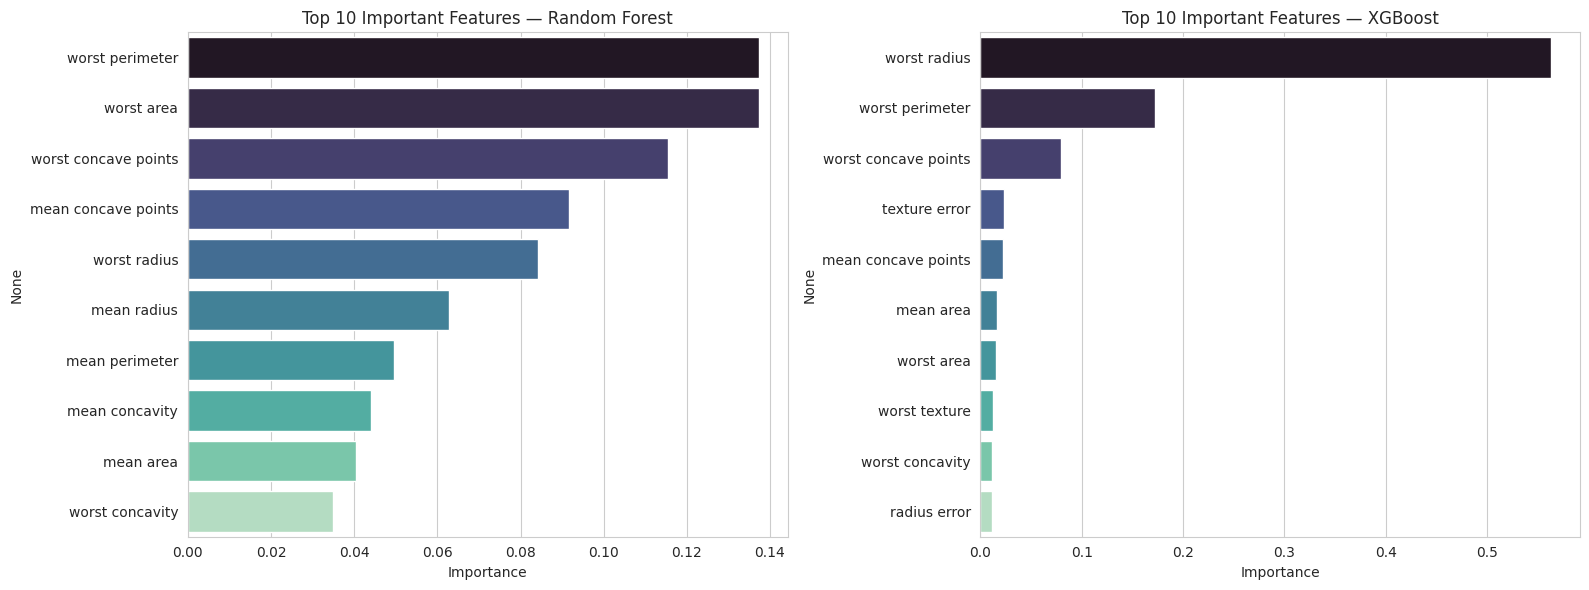

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name in zip(axes, ["Random Forest", "XGBoost"]):
    model = trained_models[name]
    importances = pd.Series(model.feature_importances_, index=X.columns)
    top10 = importances.sort_values(ascending=False).head(10)
    sns.barplot(x=top10.values, y=top10.index, ax=ax, palette="mako")
    ax.set_title(f"Top 10 Important Features — {name}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()


## 9️⃣ Predicting on a New / Sample Patient Record

Example: take one row from the test set and show how the trained pipeline predicts it (as would happen with a new patient's lab measurements).


In [38]:
sample_idx = 0
sample = X_test.iloc[[sample_idx]]
sample_scaled = scaler.transform(sample)

actual = target_names[y_test.iloc[sample_idx]]

print("Sample patient features (first 5 shown):")
print(sample.iloc[:, :5])
print("\nActual diagnosis:", actual)
print("-" * 40)

for name, model in trained_models.items():
    pred = model.predict(sample_scaled)[0]
    proba = model.predict_proba(sample_scaled)[0][1]
    print(f"{name:22s} → Predicted: {target_names[pred]:10s} | P(benign) = {proba:.3f}")


Sample patient features (first 5 shown):
     mean radius  mean texture  mean perimeter  mean area  mean smoothness
256        19.55         28.77           133.6     1207.0           0.0926

Actual diagnosis: malignant
----------------------------------------
Logistic Regression    → Predicted: malignant  | P(benign) = 0.000
SVM (RBF Kernel)       → Predicted: malignant  | P(benign) = 0.001
Random Forest          → Predicted: malignant  | P(benign) = 0.000
XGBoost                → Predicted: malignant  | P(benign) = 0.000


## 🔟 Conclusion

- All four models perform well on this dataset, typically reaching **95–99% accuracy**, since the Breast Cancer Wisconsin dataset is relatively clean and well-separated.
- **Cross-validation** confirms the results are stable and not due to a lucky train/test split.
- The **feature importance** plots show that features like `worst concave points`, `worst radius`, `mean concave points`, and `worst area` are among the strongest predictors of malignancy — consistent with medical literature.
- For a real clinical deployment, **Recall** on the malignant class matters most (minimizing false negatives), so it is worth optimizing the classification threshold, not just relying on default 0.5.

### 🔧 Possible Next Steps
- Hyperparameter tuning (GridSearchCV / RandomizedSearchCV / Optuna) for each model.
- Try feature selection / dimensionality reduction (PCA) to simplify the model.
- Calibrate probabilities (`CalibratedClassifierCV`) for more reliable risk scores.
- Build a similar pipeline for the **Heart Disease** and **Diabetes** UCI datasets, reusing this same structure.
- Wrap the best model in a simple API (FastAPI/Flask) or Streamlit app for interactive predictions.
